D:\ANACONDA\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - accuracy: 0.3542 - loss: 1.7428 - val_accuracy: 0.5070 - val_loss: 1.3915
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.5166 - loss: 1.3592 - val_accuracy: 0.5647 - val_loss: 1.2207
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.5818 - loss: 1.1942 - val_accuracy: 0.6246 - val_loss: 1.0567
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.6240 - loss: 1.0724 - val_accuracy: 0.6480 - val_loss: 1.0076
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.6545 - loss: 0.9901 - val_accuracy: 0.6680 - val_loss: 0.9417
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.6826 - loss: 0.9124 - val_accuracy: 0.6873 - val_loss: 0.9102
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.7069 - loss: 0.8515 - val_accuracy: 0.7040 - val_loss: 0.8530
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.7194 - loss: 0.7983 - 

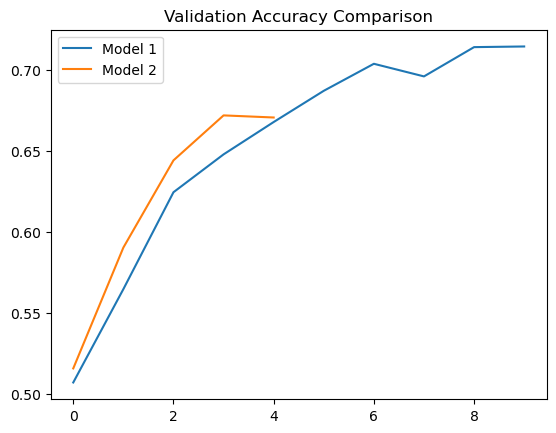

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

def build_model(learning_rate=0.001, dropout_rate=0.5, filters=32):
    model = Sequential()
    # Conv Layer 1
    model.add(Conv2D(filters, (3,3), activation='relu', input_shape=(32,32,3)))
    model.add(MaxPooling2D((2,2)))
    # Conv Layer 2
    model.add(Conv2D(filters*2, (3,3), activation='relu'))
    model.add(MaxPooling2D((2,2)))
    # Conv Layer 3
    model.add(Conv2D(filters*4, (3,3), activation='relu'))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(10, activation='softmax'))
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model1 = build_model(learning_rate=0.001, dropout_rate=0.5, filters=32)
history1 = model1.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

model2 = build_model(learning_rate=0.0005, dropout_rate=0.3, filters=64)
history2 = model2.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

loss1, acc1 = model1.evaluate(X_test, y_test)
loss2, acc2 = model2.evaluate(X_test, y_test)

print("Model 1 Accuracy:", acc1)
print("Model 2 Accuracy:", acc2)

plt.plot(history1.history['val_accuracy'], label='Model 1')
plt.plot(history2.history['val_accuracy'], label='Model 2')
plt.legend()
plt.title("Validation Accuracy Comparison")
plt.show()
